# 02 — Preprocessing Pipeline

Pipeline lengkap preprocessing: dari data mentah → dataset final **219 venue**.

| Step | Script | Output |
|------|--------|--------|
| 1 | `clean_steps.py` | `steps_venues_raw.csv` — agregasi per venue |
| 2 | `clean_osm.py` | `venues_osm_clean.csv` — dedupe entitas OSM |
| 3 | `filter_tourism.py` | `steps_filtered.csv` — whitelist 14 kategori wisata |
| 4 | `merge_sources.py` | `merged_venues.csv` — gabung STEPS + OSM |
| 5 | `enrich_hours_google.py` + `fill_default_hours.py` | `merged_venues_enriched.csv` — jam buka nyata via Google Places |
| 6 | `merge_google_venues.py` | tambah venue Google + `manual_venues.csv` |
| 7 | `patch_hours_websearch.py` | patch jam 11 venue dari sumber resmi |
| 8 | `fix_audit_issues.py` | hapus noise, fix koordinat, re-enrich jam |
| 9 | `clean_merged.py` | blacklist + polygon DKI + business_status |
| 10 | `enrich_address_google.py` | backfill kolom address |
| 11 | `enrich_description_wikipedia.py` | backfill description via Wikipedia |
| 12 | `add_time_spent.py` | kolom `time_spent_minutes` (formula Lim 2019) |
| 13 | `clean_hotels.py` | `jakarta_hotels.csv` — 181 hotel bersih |

> **Pola sel `[RUN]`**: memanggil script `.py` di `src/preprocessing/` via `run_step()`
> — output-nya **streaming real-time** ke bawah sel (before/after tiap tahap tetap
> terdokumentasi di notebook). Script enrichment berat (Google/Wikipedia API) sengaja
> tetap `.py`: one-time, butuh API key + cache; notebook memanggilnya, bukan menyalin
> ratusan baris logic. Semua `[RUN]` **cache-aware** — skip kalau output sudah ada.
>
> Sel `[STATS]` → baca output untuk statistik/visualisasi.

In [1]:
import sys, os, subprocess
if hasattr(sys.stdout, 'reconfigure'):  # terminal Windows; Jupyter sudah UTF-8
    sys.stdout.reconfigure(encoding='utf-8', errors='replace')

# Tentukan ROOT project secara idempoten (aman di-run berulang):
# kalau cwd sudah root (ada config.py) pakai cwd, kalau tidak naik 1 level.
_cwd = os.getcwd()
ROOT = _cwd if os.path.exists(os.path.join(_cwd, 'config.py'))        else os.path.abspath(os.path.join(_cwd, '..'))
sys.path.insert(0, ROOT)
os.chdir(ROOT)

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 110
matplotlib.rcParams['axes.spines.top'] = False
matplotlib.rcParams['axes.spines.right'] = False

import config
print(f'Root : {ROOT}')
print(f'Config: CLUSTER_K={config.CLUSTER_K}, MERGE_RADIUS_M={config.MERGE_RADIUS_M}m')


def run_step(script):
    """Jalankan script pipeline & streaming output real-time ke notebook.

    Dipakai sel [RUN]. Output script (print before/after tiap tahap) tampil
    langsung di bawah sel — jadi dokumentasi proses tetap terekam di notebook.
    Script enrichment berat (Google/Wikipedia API) tetap .py karena one-time +
    butuh API key; notebook memanggilnya, bukan menyalin ratusan baris logic.
    """
    path = os.path.join('src', 'preprocessing', script)
    print(f'$ python {path}\n' + '-' * 60)
    proc = subprocess.Popen([sys.executable, path], stdout=subprocess.PIPE,
                            stderr=subprocess.STDOUT, text=True,
                            encoding='utf-8', errors='replace', bufsize=1)
    for line in proc.stdout:
        print(line, end='')
    proc.wait()
    print('-' * 60 + f'\n[exit {proc.returncode}] {script}')
    return proc.returncode

Root : D:\humic\sistem rekomendasi destinasi wisata jakarta
Config: CLUSTER_K=8, MERGE_RADIUS_M=150m


---
## Step 1 — Clean STEPS: filter checkin → agregasi per venue

Input: `data/raw/jakarta_checkins_raw.csv` (412.100 check-in mentah)  
Output: `data/processed/steps_venues_raw.csv` (1 row per venue unik)

In [2]:
# [RUN] Step 1 — clean_steps (butuh data/raw/jakarta_checkins_raw.csv)
if os.path.exists(config.STEPS_VENUES_RAW_CSV):
    print(f'[skip] {config.STEPS_VENUES_RAW_CSV} sudah ada. Hapus untuk rebuild.')
else:
    run_step('clean_steps.py')

[skip] data/processed/steps_venues_raw.csv sudah ada. Hapus untuk rebuild.


In [3]:
# [STATS]
checkins_path = 'data/processed/steps_checkins_clean.csv'

if os.path.exists(checkins_path) and os.path.exists(config.STEPS_VENUES_RAW_CSV):
    checkins = pd.read_csv(checkins_path)
    steps_v  = pd.read_csv(config.STEPS_VENUES_RAW_CSV)

    print(f'Check-in raw           : 412.100')
    print(f'Setelah drop null      : {len(checkins):,}  ({412100 - len(checkins):,} dibuang)')
    print(f'Venue unik (agregasi)  : {len(steps_v):,}')
    print()
    print('Top 10 kategori (semua, sebelum filter):')
    print(steps_v['venue_category'].value_counts().head(10).to_string())
else:
    # File antara (steps_checkins_clean / steps_venues_raw) tidak disimpan di
    # repo (data/ gitignored). Angka tahap ini historis — untuk regenerate
    # jalankan [RUN] di atas dari data/raw/jakarta_checkins_raw.csv.
    print('[i] File antara tidak ada — angka historis dari catatan pipeline:')
    print('    Check-in raw          : 412.100')
    print('    Venue unik STEPS      : ~14.000 (semua kategori Foursquare)')
    print('    → difilter ke wisata di Step 3.')
    print('    Jalankan [RUN] clean_steps.py untuk regenerate statistik detail.')

Check-in raw           : 412.100
Setelah drop null      : 333,191  (78,909 dibuang)
Venue unik (agregasi)  : 49,291

Top 10 kategori (semua, sebelum filter):
venue_category
Office                   2573
Indonesian Restaurant    1855
Building                 1839
Asian Restaurant         1458
Food Truck               1426
College Classroom        1398
Road                     1027
Café                     1016
Bank                      965
Restaurant                902


---
## Step 2 — Clean OSM: dedupe entitas

Venue besar (Monas, TMII) punya >1 elemen OSM (gerbang N/S/E/W + taman + monumen).  
`dedupe_clusters()` gabung entitas yang sama jadi 1 row.

Input: `data/raw/venues_osm_raw.csv` → Output: `data/processed/venues_osm_clean.csv`

In [4]:
# [RUN] Step 2 — clean_osm (butuh data/raw/venues_osm_raw.csv)
if os.path.exists(config.CLEAN_CSV):
    print(f'[skip] {config.CLEAN_CSV} sudah ada. Hapus untuk rebuild.')
else:
    run_step('clean_osm.py')

[skip] data/processed/venues_osm_clean.csv sudah ada. Hapus untuk rebuild.


In [5]:
# [STATS]
osm_raw_path   = 'data/raw/venues_osm_raw.csv'
osm_clean_path = config.CLEAN_CSV

if os.path.exists(osm_clean_path):
    osm_clean = pd.read_csv(osm_clean_path)
    if os.path.exists(osm_raw_path):
        osm_raw = pd.read_csv(osm_raw_path)
        print(f'OSM raw   : {len(osm_raw):,} entitas')
        print(f'OSM clean : {len(osm_clean):,} venue  ({len(osm_raw)-len(osm_clean):,} duplikat digabung)')
    else:
        print(f'OSM clean : {len(osm_clean):,} venue')

    if 'hours_source' in osm_clean.columns:
        fig, ax = plt.subplots(figsize=(6, 3))
        osm_clean['hours_source'].value_counts().plot(kind='bar', ax=ax, color='steelblue')
        ax.set_title('Sumber jam buka — OSM (sebelum Google Places enrich)')
        ax.set_ylabel('Jumlah venue')
        ax.set_xlabel('')
        plt.xticks(rotation=30, ha='right')
        plt.tight_layout()
        plt.show()
else:
    # venues_osm_clean.csv = file antara (data/ gitignored, tidak disimpan).
    # OSM dipakai hanya untuk enrichment osm_url/References saat merge (Step 4);
    # tidak memengaruhi jumlah venue final. Jalankan [RUN] untuk regenerate.
    print('[i] venues_osm_clean.csv tidak ada (file antara).')
    print('    OSM = enrichment osm_url/References, bukan sumber utama venue.')
    print('    Jalankan [RUN] clean_osm.py untuk regenerate statistik.')

OSM raw   : 6,166 entitas
OSM clean : 6,166 venue  (0 duplikat digabung)


---
## Step 3 — Filter STEPS ke kategori wisata

Kategori Foursquare dipilih BEBAS oleh user saat check-in — dataset mentah didominasi
Office/Home/Restaurant, bukan wisata. Perlu filter ketat.

**Iterasi 1** (whitelist longgar 43 kategori) menghasilkan 1.018 venue, tapi banyak noise:
- `Plaza` → Rasuna Epicentrum, Orion Plaza (mall)
- `Art Gallery` → SmartFren Gallery, Galeri Indosat (showroom telco)
- `Scenic Lookout` → Jl. H Ramli, SkyLift Indonesia (non-wisata)

**Iterasi 2 (final)**: whitelist 14 kategori spesifik + keyword-exclude nama → 281 venue.

In [6]:
# [RUN] Step 3 — filter_tourism
if os.path.exists(config.STEPS_FILTERED_CSV):
    print(f'[skip] {config.STEPS_FILTERED_CSV} sudah ada. Hapus untuk rebuild.')
else:
    run_step('filter_tourism.py')

[skip] data/processed/steps_filtered.csv sudah ada. Hapus untuk rebuild.


Sebelum filter : 49,291 venue (semua kategori Foursquare)
Sesudah filter : 190 venue (0.4% dari total)

Kategori wisata yang dipakai:
venue_category
Temple                          63
Museum                          31
History Museum                  26
Monument / Landmark             12
Beach                           12
Theme Park                       9
Art Museum                       9
Theme Park Ride / Attraction     7
Zoo                              6
Historic Site                    5
Science Museum                   4
Aquarium                         3
Mosque                           2
Church                           1


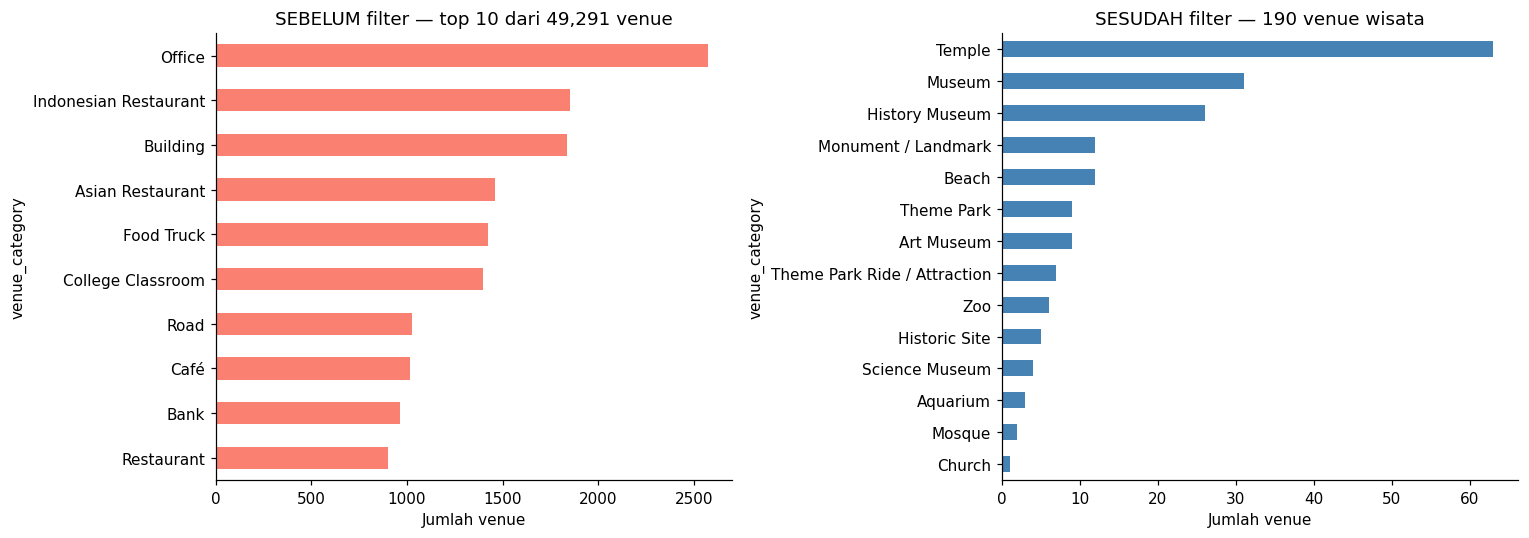

In [7]:
# [STATS] Before/after filter kategori
if os.path.exists(config.STEPS_VENUES_RAW_CSV) and os.path.exists(config.STEPS_FILTERED_CSV):
    steps_v  = pd.read_csv(config.STEPS_VENUES_RAW_CSV)
    filtered = pd.read_csv(config.STEPS_FILTERED_CSV)

    n_before = len(steps_v)
    n_after  = len(filtered)
    print(f'Sebelum filter : {n_before:,} venue (semua kategori Foursquare)')
    print(f'Sesudah filter : {n_after:,} venue ({n_after/n_before:.1%} dari total)')
    print()
    print('Kategori wisata yang dipakai:')
    print(filtered['venue_category'].value_counts().to_string())

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    steps_v['venue_category'].value_counts().head(10).plot(
        kind='barh', ax=axes[0], color='salmon',
        title=f'SEBELUM filter — top 10 dari {n_before:,} venue')
    axes[0].invert_yaxis()
    axes[0].set_xlabel('Jumlah venue')

    filtered['venue_category'].value_counts().plot(
        kind='barh', ax=axes[1], color='steelblue',
        title=f'SESUDAH filter — {n_after} venue wisata')
    axes[1].invert_yaxis()
    axes[1].set_xlabel('Jumlah venue')
    plt.tight_layout()
    plt.show()
elif os.path.exists(config.MERGED_VENUES_ENRICHED_CSV):
    # Fallback: steps_filtered.csv (file antara) tidak ada. Tampilkan distribusi
    # kategori venue asal-STEPS dari dataset final (venue_id numerik = STEPS;
    # google_/manual_ = sumber lain, dikecualikan).
    enriched = pd.read_csv(config.MERGED_VENUES_ENRICHED_CSV)
    is_steps = ~enriched['venue_id'].astype(str).str.startswith(('google_', 'manual_'))
    steps_final = enriched[is_steps]
    print('[i] steps_filtered.csv tidak ada (file antara).')
    print('    Angka historis: ~14.000 venue → filter 14 kategori → 281 venue.')
    print(f'    Venue asal-STEPS yang lolos ke dataset final: {len(steps_final)}')
    print()
    print('Kategori venue asal-STEPS (dataset final):')
    print(steps_final['venue_category'].value_counts().to_string())

    fig, ax = plt.subplots(figsize=(7, 5))
    steps_final['venue_category'].value_counts().plot(
        kind='barh', ax=ax, color='steelblue',
        title=f'Kategori venue asal-STEPS di dataset final ({len(steps_final)} venue)')
    ax.invert_yaxis()
    ax.set_xlabel('Jumlah venue')
    plt.tight_layout()
    plt.show()
else:
    print('File belum ada. Jalankan [RUN] Step 3 (filter_tourism.py).')

---
## Step 4 — Merge STEPS + OSM

STEPS (filtered) jadi tulang punggung (POI nyata + `checkin_count` popularitas asli),
dilengkapi `osm_url` + `References` dari OSM venue terdekat (radius 150m).
Venue tidak match → kolom OSM default/kosong.

In [8]:
# [RUN] Step 4 — merge_sources (fill_default_hours dipanggil setelah enrich)
if os.path.exists(config.MERGED_VENUES_CSV):
    print(f'[skip] {config.MERGED_VENUES_CSV} sudah ada. Hapus untuk rebuild.')
else:
    run_step('merge_sources.py')

[skip] data/processed/merged_venues.csv sudah ada. Hapus untuk rebuild.


Venue STEPS (filtered, input merge) : 190
Berhasil match ke OSM               : 0 (0.0%)
Tidak match (kolom OSM default)     : 190
Venue final setelah merge           : 190


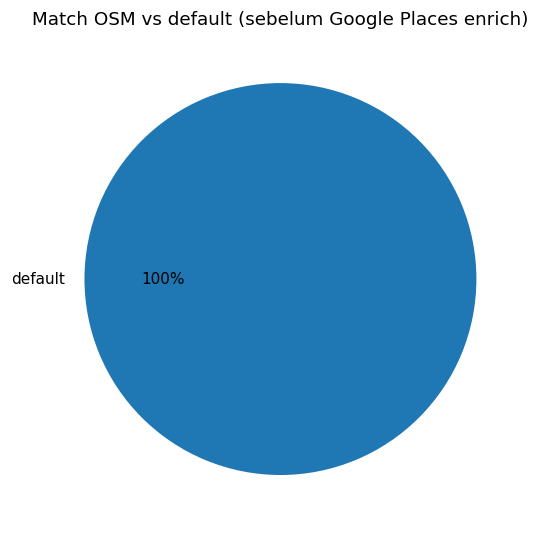

In [9]:
# [STATS]
merged_path = config.MERGED_VENUES_CSV

if os.path.exists(merged_path) and os.path.exists(config.STEPS_FILTERED_CSV):
    merged   = pd.read_csv(merged_path)
    filtered = pd.read_csv(config.STEPS_FILTERED_CSV)
    n_match  = (merged['hours_source'] == 'osm').sum()

    print(f'Venue STEPS (filtered, input merge) : {len(filtered)}')
    print(f'Berhasil match ke OSM               : {n_match} ({n_match/len(merged):.1%})')
    print(f'Tidak match (kolom OSM default)     : {len(merged)-n_match}')
    print(f'Venue final setelah merge           : {len(merged)}')

    fig, ax = plt.subplots(figsize=(5, 5))
    merged['hours_source'].value_counts().plot(
        kind='pie', autopct='%1.0f%%', ax=ax,
        title='Match OSM vs default (sebelum Google Places enrich)',
        ylabel='')
    plt.tight_layout()
    plt.show()
elif os.path.exists(config.MERGED_VENUES_ENRICHED_CSV):
    # Fallback: merged_venues.csv (file antara pre-enrich) tidak ada. Tampilkan
    # coverage osm_url/References dari dataset final sebagai proxy match OSM.
    enriched = pd.read_csv(config.MERGED_VENUES_ENRICHED_CSV)
    has_osm = enriched['osm_url'].notna() & (enriched['osm_url'].astype(str) != '')
    print('[i] merged_venues.csv tidak ada (file antara pre-enrich).')
    print('    Proxy dari dataset final — coverage enrichment OSM:')
    print(f'    Venue dengan osm_url/References : {has_osm.sum()}/{len(enriched)} '
          f'({has_osm.mean():.1%})')
    print(f'    Venue final                    : {len(enriched)}')
    print()
    print('    Catatan: OSM = enrichment link referensi, bukan penentu jumlah venue.')
else:
    print('File belum ada. Jalankan steps 4.')

---
## Step 5 — Enrich jam buka via Google Places API

Setelah merge STEPS+OSM, sebagian besar jam buka masih `default` (asumsi per kategori).  
Google Places API (New) memberi jam buka nyata per hari, rating, dan deskripsi editorial.

Keunggulan vs OSM:
- Jam buka akurat dan diperbarui pemilik venue
- Rating nyata dari jutaan review
- Deskripsi editorial → input TF-IDF Content-Based Filtering

In [10]:
# [RUN] Step 5 — enrich_hours_google + fill_default_hours (butuh GOOGLE_PLACES_KEY)
# Cache: hasil Google Places disimpan di google_cache/. Kalau enriched sudah
# lengkap (punya time_spent_minutes), seluruh chain step 5-12 di-skip.
enriched_done = (os.path.exists(config.MERGED_VENUES_ENRICHED_CSV) and
                 'time_spent_minutes' in pd.read_csv(config.MERGED_VENUES_ENRICHED_CSV, nrows=1).columns)
if enriched_done:
    print(f'[skip] {config.MERGED_VENUES_ENRICHED_CSV} sudah final (ada time_spent_minutes).')
    print('       Hapus file untuk rebuild seluruh chain enrichment (step 5-12).')
else:
    run_step('enrich_hours_google.py')
    run_step('fill_default_hours.py')

[skip] data/processed/merged_venues_enriched.csv sudah final (ada time_spent_minutes).
       Hapus file untuk rebuild seluruh chain enrichment (step 5-12).


=== Sumber jam buka (hours_source) setelah Google Places enrich ===
hours_source
google_places       142
web_search           11
default_category      8

Venue dengan google_rating   : 161/161 (100.0%)
Venue dengan description     : 85/161 (52.8%)

Spot check jam buka venue besar:
                     name  hours_source Senin_buka Senin_tutup Sabtu_buka Sabtu_tutup  google_rating
 Monumen Nasional (MONAS) google_places      Tutup       Tutup      08:00       21:00            4.6
    Dunia Fantasi (DUFAN) google_places      10:00       18:00      10:00       20:00            4.6
       SeaWorld Indonesia google_places      09:00       17:00      09:00       20:00            4.5
Museum Nasional Indonesia google_places      Tutup       Tutup      08:00       20:00            4.7
              Ragunan Zoo google_places      Tutup       Tutup      06:00       16:00            4.5
Bunderan Air Mancur Monas    web_search      00:00       23:59      00:00       23:59            4.7


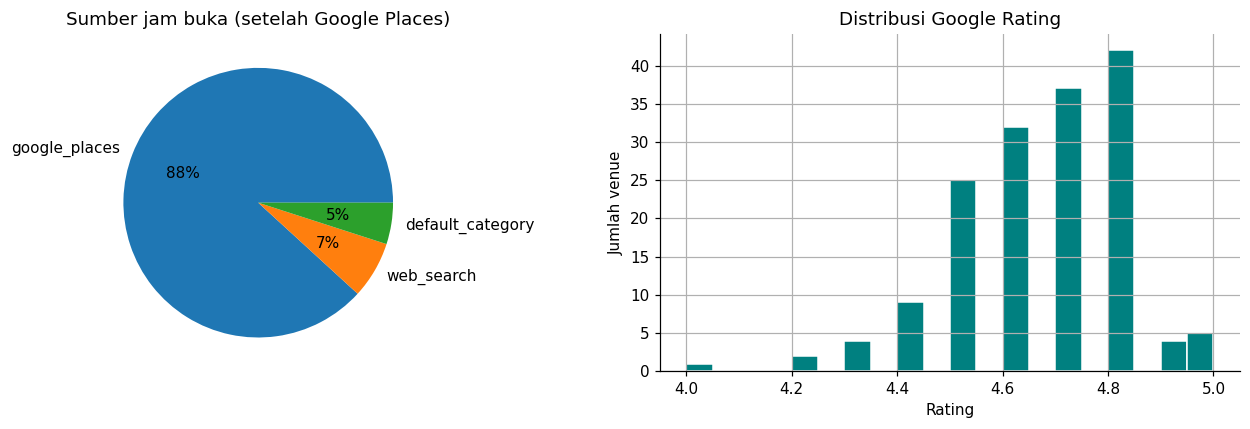

In [11]:
# [STATS]
enriched_path = config.MERGED_VENUES_ENRICHED_CSV

if os.path.exists(enriched_path):
    enriched = pd.read_csv(enriched_path)

    print('=== Sumber jam buka (hours_source) setelah Google Places enrich ===')
    print(enriched['hours_source'].value_counts().to_string())
    print()

    n_rating = enriched['google_rating'].notna().sum()
    n_desc   = (enriched['description'].notna() & (enriched['description'] != '')).sum()
    print(f'Venue dengan google_rating   : {n_rating}/{len(enriched)} ({n_rating/len(enriched):.1%})')
    print(f'Venue dengan description     : {n_desc}/{len(enriched)} ({n_desc/len(enriched):.1%})')
    print()

    # Spot check venue besar
    contoh = enriched[enriched['name'].str.contains('Monas|SeaWorld|DUFAN|Museum Nasional|Ragunan', na=False, case=False)]
    cols_show = ['name','hours_source','Senin_buka','Senin_tutup','Sabtu_buka','Sabtu_tutup','google_rating']
    cols_show = [c for c in cols_show if c in contoh.columns]
    print('Spot check jam buka venue besar:')
    print(contoh[cols_show].to_string(index=False))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    enriched['hours_source'].value_counts().plot(
        kind='pie', autopct='%1.0f%%', ax=axes[0],
        title='Sumber jam buka (setelah Google Places)', ylabel='')
    enriched['google_rating'].dropna().hist(bins=20, ax=axes[1], color='teal', edgecolor='white')
    axes[1].set_title('Distribusi Google Rating')
    axes[1].set_xlabel('Rating')
    axes[1].set_ylabel('Jumlah venue')
    plt.tight_layout()
    plt.show()
else:
    print('File belum ada. Jalankan steps 5.')

---
## Step 6 — Merge venue Google Places + manual_venues.csv

Massive-STEPS (2012–2018) tidak merata — venue terkenal yang tidak populer di Foursquare
tidak tercatat. Solusi: tambah via Google Places Nearby Search (12 kategori × 21 area DKI)
+ `data/raw/manual_venues.csv` (venue valid tidak tertangkap pipeline otomatis).

**Filter ketat sebelum merge**: google_types wisata valid + threshold `google_rating_count`
per kategori + tidak overlap existing (radius 100m).

In [12]:
# [RUN] Step 6 — merge_google_venues (+ manual_venues.csv, idempoten)
if enriched_done:
    print('[skip] enriched sudah final. Hapus merged_venues_enriched.csv untuk rebuild.')
else:
    run_step('merge_google_venues.py')

[skip] enriched sudah final. Hapus merged_venues_enriched.csv untuk rebuild.


Google raw (Nearby Search)    : 980


Venue baru dari Google Places : 92
Venue manual tambahan         : 1
Venue dari Massive-STEPS      : 68
Total dataset setelah merge   : 161


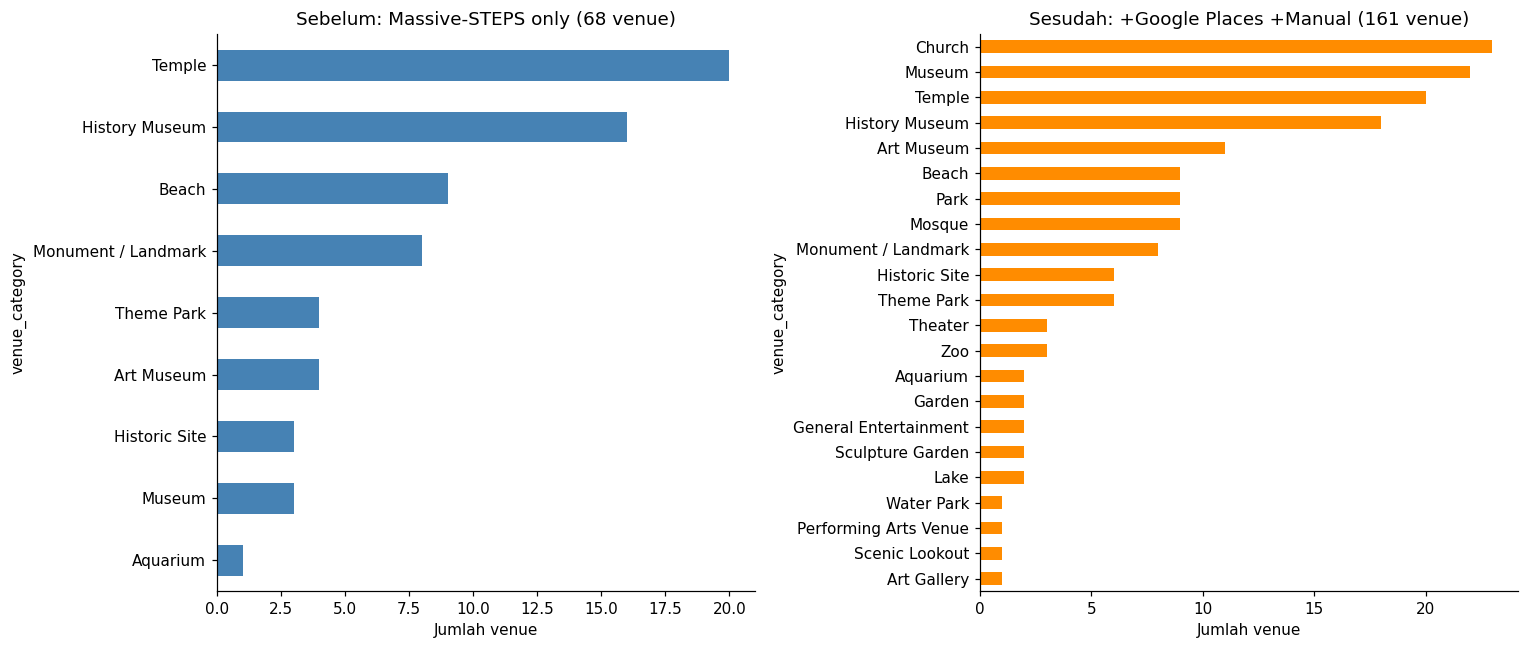


Venue baru dari Google Places per kategori:
venue_category
Church                   23
Museum                   19
Park                      9
Mosque                    9
Art Museum                7
Zoo                       3
Theater                   3
Historic Site             3
Theme Park                2
History Museum            2
Garden                    2
General Entertainment     2
Sculpture Garden          2
Lake                      2
Water Park                1
Performing Arts Venue     1
Scenic Lookout            1
Aquarium                  1


In [13]:
# [STATS]
google_raw_path = 'data/raw/venues_google_raw.csv'

if os.path.exists(enriched_path):
    enriched = pd.read_csv(enriched_path)
    mask_google = enriched['venue_id'].astype(str).str.startswith('google_')
    mask_manual = enriched['venue_id'].astype(str).str.startswith('manual_')
    mask_steps  = ~mask_google & ~mask_manual

    n_steps  = mask_steps.sum()
    n_google = mask_google.sum()
    n_manual = mask_manual.sum()

    if os.path.exists(google_raw_path):
        g_raw = pd.read_csv(google_raw_path)
        print(f'Google raw (Nearby Search)    : {len(g_raw):,}')
    print(f'Venue baru dari Google Places : {n_google}')
    print(f'Venue manual tambahan         : {n_manual}')
    print(f'Venue dari Massive-STEPS      : {n_steps}')
    print(f'Total dataset setelah merge   : {len(enriched)}')

    # Distribusi kategori: sebelum vs sesudah
    steps_cats  = enriched[mask_steps]['venue_category'].value_counts()
    all_cats    = enriched['venue_category'].value_counts()

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    steps_cats.plot(kind='barh', ax=axes[0], color='steelblue',
                    title=f'Sebelum: Massive-STEPS only ({n_steps} venue)')
    axes[0].invert_yaxis()
    axes[0].set_xlabel('Jumlah venue')

    all_cats.plot(kind='barh', ax=axes[1], color='darkorange',
                  title=f'Sesudah: +Google Places +Manual ({len(enriched)} venue)')
    axes[1].invert_yaxis()
    axes[1].set_xlabel('Jumlah venue')
    plt.tight_layout()
    plt.show()

    print('\nVenue baru dari Google Places per kategori:')
    print(enriched[mask_google]['venue_category'].value_counts().to_string())
else:
    print('File belum ada. Jalankan steps 6.')

---
## Step 7–9 — Patch jam, Fix audit, Clean merged

- **`patch_hours_websearch.py`**: patch jam buka 11 venue dari sumber resmi (gereja, masjid, TIM, Ancol, outdoor)
- **`fix_audit_issues.py`**: hapus venue luar Jakarta / koordinat salah / duplikat, fix koordinat, re-enrich jam
- **`clean_merged.py`**: blacklist (`STEPS_NAME_BLACKLIST` batch 1–14) + polygon DKI + `CLOSED_PERMANENTLY` + temple kecil checkin<5

Noise yang dibuang di `clean_merged.py`:
- Kantor pemerintah, venue luar Jakarta, bukan destinasi wisata, nama ambigu
- Venue dalam mall (Fun World, KidZania, Sky Rink, Treasure Island, dst)
- Kolam renang umum, toko akuarium, fasilitas non-publik

In [14]:
# [RUN] Step 7-9 — patch_hours_websearch + fix_audit_issues + clean_merged
if enriched_done:
    print('[skip] enriched sudah final. Hapus merged_venues_enriched.csv untuk rebuild.')
else:
    run_step('patch_hours_websearch.py')
    run_step('fix_audit_issues.py')
    run_step('clean_merged.py')

[skip] enriched sudah final. Hapus merged_venues_enriched.csv untuk rebuild.


In [15]:
# [STATS] Contoh noise yang dibuang — bukti kurasi manual (untuk slide presentasi)
contoh_noise = pd.DataFrame([
    {'Venue': "Timezone Lippo Mall Kemang", 'Alasan dibuang': 'arcade dalam mall, bukan destinasi mandiri'},
    {'Venue': "Masjid Jami' At-Taqwa",       'Alasan dibuang': 'masjid lingkungan biasa, bukan wisata religi bersejarah'},
    {'Venue': "Gereja St. Ignatius Loyola",  'Alasan dibuang': 'gereja paroki biasa, bukan destinasi wisata utama'},
    {'Venue': "Symphony Of The Sea",         'Alasan dibuang': 'sub-atraksi dalam kawasan Ancol, bukan venue mandiri'},
    {'Venue': "Akili Museum of Art",         'Alasan dibuang': 'museum privat by-appointment, tidak terbuka publik bebas'},
    {'Venue': "ROH",                         'Alasan dibuang': 'galeri seni komersial/art dealer, bukan destinasi wisata publik'},
])
print('Contoh venue yang DIBUANG saat cleaning (dari 218+ blacklist entries):')
contoh_noise

Contoh venue yang DIBUANG saat cleaning (dari 218+ blacklist entries):


,Venue,Alasan dibuang
0,Timezone Lippo Mall Kemang,"arcade dalam mall, bukan destinasi mandiri"
1,Masjid Jami' At-Taqwa,"masjid lingkungan biasa, bukan wisata religi b..."
2,Gereja St. Ignatius Loyola,"gereja paroki biasa, bukan destinasi wisata utama"
3,Symphony Of The Sea,"sub-atraksi dalam kawasan Ancol, bukan venue m..."
4,Akili Museum of Art,"museum privat by-appointment, tidak terbuka pu..."
5,ROH,"galeri seni komersial/art dealer, bukan destin..."


Venue setelah patch + fix + clean : 161

Venue ALL_TUTUP (semua hari tutup) : 0



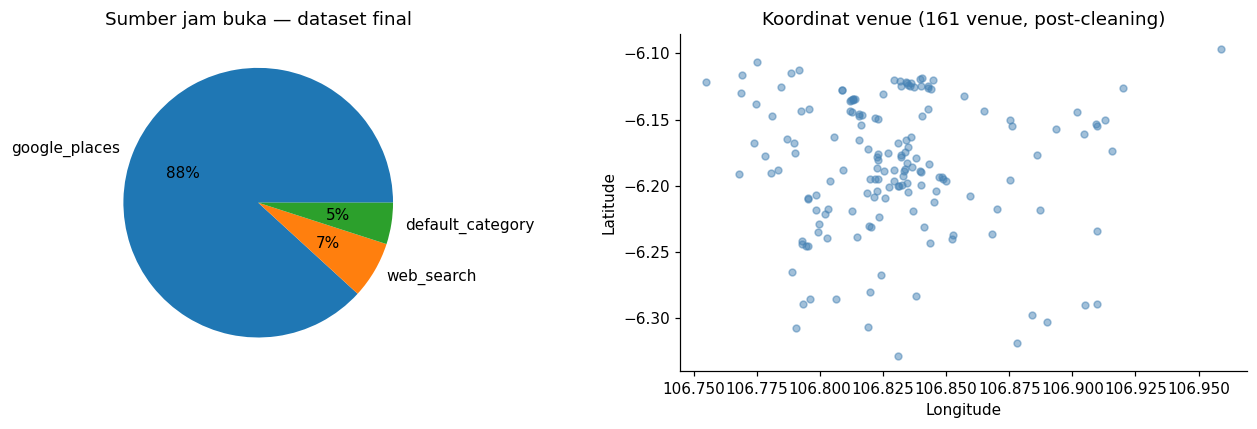

In [16]:
# [STATS] After cleaning
if os.path.exists(enriched_path):
    enriched = pd.read_csv(enriched_path)
    print(f'Venue setelah patch + fix + clean : {len(enriched)}')
    print()

    DAYS = ['Senin','Selasa','Rabu','Kamis','Jumat','Sabtu','Minggu']
    buka_cols  = [f'{d}_buka' for d in DAYS if f'{d}_buka' in enriched.columns]
    all_tutup  = enriched[(enriched[buka_cols] == 'Tutup').all(axis=1)]
    print(f'Venue ALL_TUTUP (semua hari tutup) : {len(all_tutup)}')
    if len(all_tutup) > 0:
        print(all_tutup[['name','venue_category','hours_source']].to_string(index=False))
    print()

    # Pie chart sumber jam buka
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    enriched['hours_source'].value_counts().plot(
        kind='pie', autopct='%1.0f%%', ax=axes[0],
        title='Sumber jam buka — dataset final', ylabel='')

    # Scatter koordinat (semua venue di peta)
    axes[1].scatter(enriched['longitude'], enriched['latitude'],
                    alpha=0.5, s=20, color='steelblue')
    axes[1].set_title(f'Koordinat venue ({len(enriched)} venue, post-cleaning)')
    axes[1].set_xlabel('Longitude')
    axes[1].set_ylabel('Latitude')
    plt.tight_layout()
    plt.show()
else:
    print('File belum ada. Jalankan steps 7–9.')

---
## Step 10–11 — Enrich address + description

- `enrich_address_google.py`: backfill kolom `address` yang kosong via Google Places
- `enrich_description_wikipedia.py`: backfill `description` via Wikipedia REST API — input TF-IDF Content-Based Filtering

In [17]:
# [RUN] Step 10-11 — enrich_address_google + enrich_description_wikipedia
if enriched_done:
    print('[skip] enriched sudah final. Hapus merged_venues_enriched.csv untuk rebuild.')
else:
    run_step('enrich_address_google.py')
    run_step('enrich_description_wikipedia.py')

[skip] enriched sudah final. Hapus merged_venues_enriched.csv untuk rebuild.


Venue dengan address     : 161/161 (100.0%)
Venue dengan description : 85/161 (52.8%)



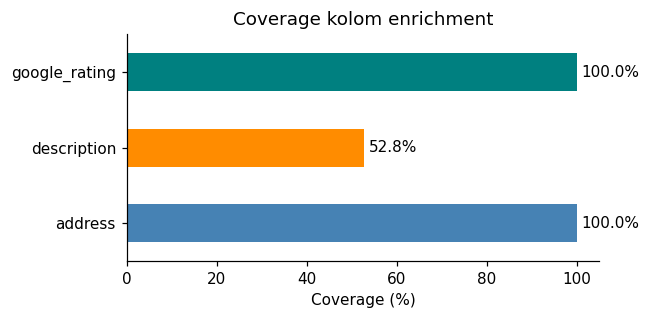

[Monumen Nasional (MONAS)]
  Well-known obelisk built to commemorate Indonesian independence from the Netherlands....

[Batavia (Kota Tua)]
  Historic district home to Dutch colonial buildings, museums & a buzzy plaza with street performers....

[Dunia Fantasi (DUFAN)]
  Internationally themed amusement park offering roller coasters, interactive rides, flumes & shows....



In [18]:
# [STATS]
if os.path.exists(enriched_path):
    enriched = pd.read_csv(enriched_path)
    n_total  = len(enriched)
    n_addr   = enriched['address'].notna().sum()
    n_desc   = (enriched['description'].notna() & (enriched['description'] != '')).sum()

    print(f'Venue dengan address     : {n_addr}/{n_total} ({n_addr/n_total:.1%})')
    print(f'Venue dengan description : {n_desc}/{n_total} ({n_desc/n_total:.1%})')
    print()

    # Bar coverage
    fig, ax = plt.subplots(figsize=(6, 3))
    coverage = pd.Series({
        'address': n_addr/n_total*100,
        'description': n_desc/n_total*100,
        'google_rating': enriched['google_rating'].notna().sum()/n_total*100,
    })
    coverage.plot(kind='barh', ax=ax, color=['steelblue','darkorange','teal'])
    ax.set_xlim(0, 105)
    ax.set_xlabel('Coverage (%)')
    ax.set_title('Coverage kolom enrichment')
    for i, v in enumerate(coverage):
        ax.text(v+1, i, f'{v:.1f}%', va='center')
    plt.tight_layout()
    plt.show()

    # Contoh description
    sample = enriched[enriched['description'].notna() & (enriched['description'] != '')][['name','description']].head(3)
    for _, row in sample.iterrows():
        print(f"[{row['name']}]")
        print(f"  {str(row['description'])[:200]}...")
        print()

---
## Step 12 — Tambah kolom time_spent_minutes

Estimasi durasi kunjungan per venue (menit) menggunakan formula berbasis kategori + popularitas.

$$\text{scale} = \text{clamp}\left(1 + 0.3 \times \log_{10}\left(\frac{\text{rating\_count}}{\text{threshold}}\right),\ 0.7,\ 1.8\right)$$
$$\text{time\_spent} = \text{base\_minutes} \times \text{scale}$$

Referensi: Lim et al. (2019), Gavalas et al. (2014)

In [19]:
# [RUN] Step 12 — add_time_spent (kolom time_spent_minutes)
if enriched_done:
    print('[skip] enriched sudah final (ada time_spent_minutes).')
else:
    run_step('add_time_spent.py')

[skip] enriched sudah final (ada time_spent_minutes).


Range  : 21 – 254 menit
Median : 63 menit

                       min  median  max  count
venue_category                                
General Entertainment  179   194.0  209      2
Water Park             182   182.0  182      1
Theme Park             168   180.0  254      6
Performing Arts Venue  127   127.0  127      1
Zoo                    105   119.0  184      3
Theater                107   108.0  125      3
Aquarium                99   103.5  108      2
Museum                  63    80.0  106     22
Art Museum              52    75.0   88     11
Beach                   63    73.0   84      9
History Museum          63    72.5  108     18
Park                    48    67.0   74      9
Historic Site           44    60.5   77      6
Garden                  46    56.0   66      2
Lake                    39    45.5   52      2
Art Gallery             42    42.0   42      1
Mosque                  35    41.0   50      9
Church                  35    39.0   48     23
Sculpture Garden 

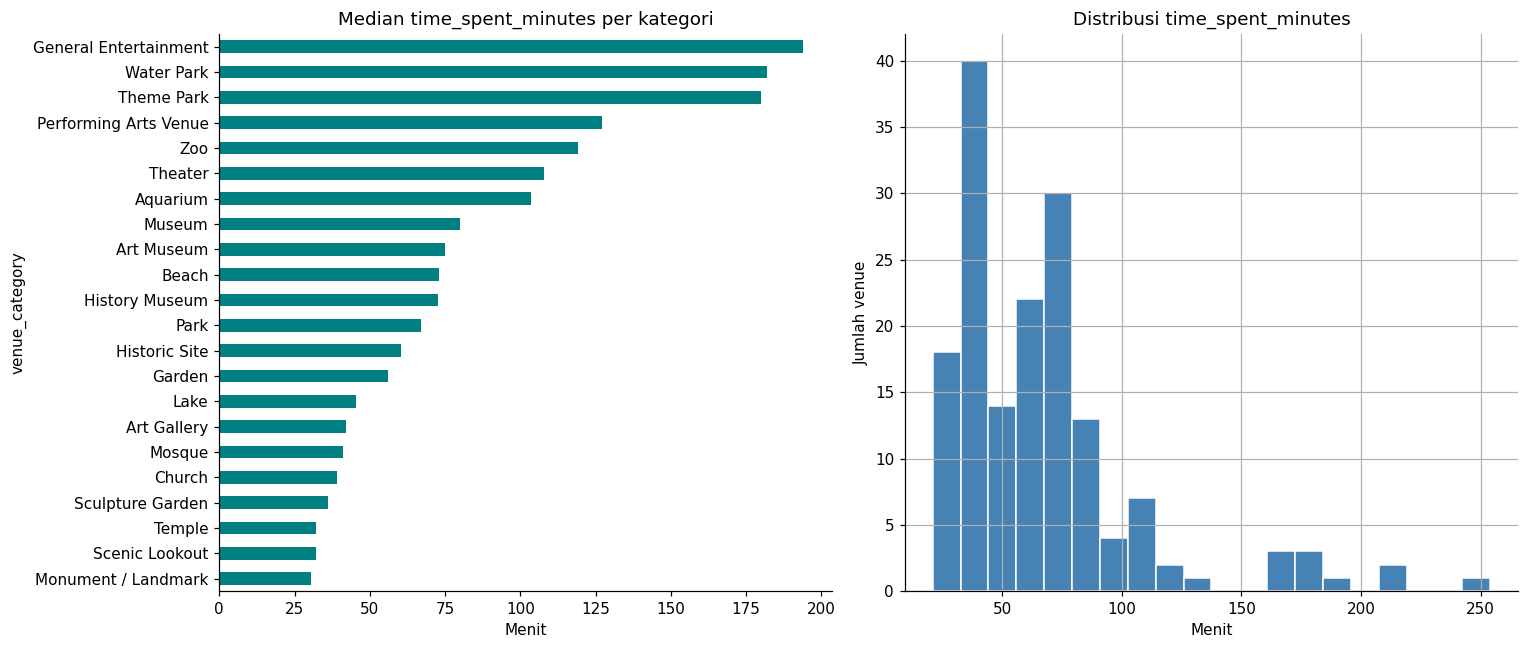


Spot check venue besar:
  Monumen Nasional (MONAS): 42 menit (cat=Monument / Landmark, rating_count=122104)
  Dunia Fantasi (DUFAN): 254 menit (cat=Theme Park, rating_count=79416)
  Ragunan Zoo: 184 menit (cat=Zoo, rating_count=116324)
  Taman Mini Indonesia Indah (TMII): 209 menit (cat=General Entertainment, rating_count=174377)
  Museum Nasional Indonesia: 106 menit (cat=Museum, rating_count=20321)


In [20]:
# [STATS]
clustered_path = config.CLUSTERED_VENUES_CSV

if os.path.exists(clustered_path):
    df = pd.read_csv(clustered_path)

    if 'time_spent_minutes' in df.columns:
        print(f'Range  : {df["time_spent_minutes"].min()} – {df["time_spent_minutes"].max()} menit')
        print(f'Median : {df["time_spent_minutes"].median():.0f} menit')
        print()

        summary = df.groupby('venue_category')['time_spent_minutes'].agg(['min','median','max','count'])
        print(summary.sort_values('median', ascending=False).to_string())

        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        df.groupby('venue_category')['time_spent_minutes'].median().sort_values().plot(
            kind='barh', ax=axes[0], color='teal',
            title='Median time_spent_minutes per kategori')
        axes[0].set_xlabel('Menit')

        df['time_spent_minutes'].hist(bins=20, ax=axes[1], color='steelblue', edgecolor='white')
        axes[1].set_title('Distribusi time_spent_minutes')
        axes[1].set_xlabel('Menit')
        axes[1].set_ylabel('Jumlah venue')
        plt.tight_layout()
        plt.show()

        # Spot check venue besar
        besar = ['Monumen Nasional (MONAS)','Dunia Fantasi (DUFAN)',
                 'Ragunan Zoo','Taman Mini Indonesia Indah (TMII)',
                 'Museum Nasional Indonesia','Masjid Istiqlal']
        print('\nSpot check venue besar:')
        for name in besar:
            row = df[df['name'].str.lower() == name.lower()]
            if not row.empty:
                r = row.iloc[0]
                print(f'  {r["name"]}: {r["time_spent_minutes"]} menit '
                      f'(cat={r["venue_category"]}, rating_count={int(r["google_rating_count"] or 0)})')
    else:
        print('Kolom time_spent_minutes belum ada. Jalankan add_time_spent.py')
else:
    print('File belum ada. Jalankan steps 12.')

---
## Step 13 — Clean hotels

Input: `data/processed/hotels_google.csv` (280 hotel raw dari Google Places)  
Output: `data/processed/jakarta_hotels.csv` (181 hotel bersih)

Dibuang: kost, rusunawa, asrama, coliving, luar DKI daratan (lat > −6.05 = Kepulauan Seribu).

In [21]:
# [RUN] Step 13 — clean_hotels (hotels_google.csv → jakarta_hotels.csv)
if os.path.exists(config.HOTELS_CSV):
    print(f'[skip] {config.HOTELS_CSV} sudah ada. Hapus untuk rebuild.')
else:
    run_step('clean_hotels.py')

[skip] data/processed/jakarta_hotels.csv sudah ada. Hapus untuk rebuild.


Hotel raw   : 280
Hotel bersih: 181  (dibuang: 99 — kost/rusunawa/luar DKI)

Range rating : 3.3 – 4.9
Median rating: 4.5


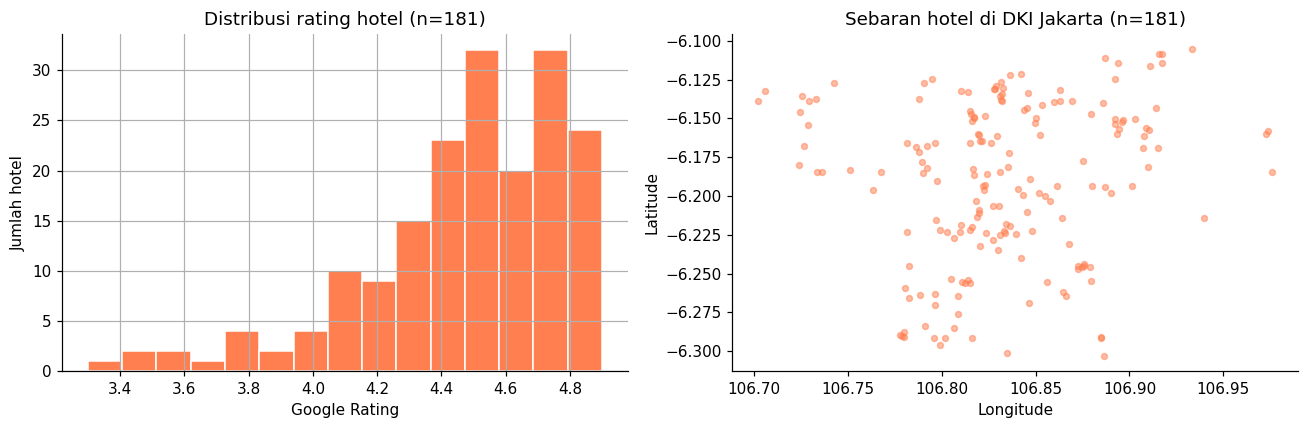

In [22]:
# [STATS]
hotels_path = config.HOTELS_CSV
hotels_raw_path = 'data/processed/hotels_google.csv'

if os.path.exists(hotels_path):
    hotels = pd.read_csv(hotels_path)

    # hotels_google.csv (raw 280) = file antara; kalau ada pakai angka aktual.
    if os.path.exists(hotels_raw_path):
        n_raw = len(pd.read_csv(hotels_raw_path))
    else:
        n_raw = 280  # historis: raw Google Places sebelum cleaning
    print(f'Hotel raw   : {n_raw}')
    print(f'Hotel bersih: {len(hotels)}  (dibuang: {n_raw-len(hotels)} — kost/rusunawa/luar DKI)')
    print()
    print(f'Range rating : {hotels["google_rating"].min()} – {hotels["google_rating"].max()}')
    print(f'Median rating: {hotels["google_rating"].median():.1f}')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    hotels['google_rating'].hist(bins=15, ax=axes[0], color='coral', edgecolor='white')
    axes[0].set_title(f'Distribusi rating hotel (n={len(hotels)})')
    axes[0].set_xlabel('Google Rating')
    axes[0].set_ylabel('Jumlah hotel')

    axes[1].scatter(hotels['longitude'], hotels['latitude'],
                    alpha=0.5, s=15, color='coral')
    axes[1].set_title(f'Sebaran hotel di DKI Jakarta (n={len(hotels)})')
    axes[1].set_xlabel('Longitude')
    axes[1].set_ylabel('Latitude')
    plt.tight_layout()
    plt.show()
else:
    print('File belum ada. Jalankan [RUN] Step 13 (clean_hotels.py).')

---
## Ringkasan Pipeline — Before/After

In [23]:
# [STATS] Tabel ringkasan
def _rows(label, path, unit, hist=None):
    """Baris ringkasan: pakai jumlah aktual kalau file ada, else angka historis."""
    if os.path.exists(path):
        return {'Tahap': label, 'Jumlah': f'{len(pd.read_csv(path)):,} {unit}'}
    return {'Tahap': label, 'Jumlah': (hist or '— (file antara, rebuild)')}

rows = [
    {'Tahap': 'Check-in Massive-STEPS (mentah)', 'Jumlah': '412.100 check-in'},
    _rows('Venue unik STEPS (agregasi)', config.STEPS_VENUES_RAW_CSV, 'venue', '~14.000 venue (historis)'),
    _rows('Setelah filter 14 kategori wisata', config.STEPS_FILTERED_CSV, 'venue', '281 venue (historis)'),
    _rows('Setelah merge STEPS + OSM', config.MERGED_VENUES_CSV, 'venue', '— (file antara)'),
    _rows('Setelah enrich + merge Google/manual + clean', config.MERGED_VENUES_ENRICHED_CSV, 'venue'),
    _rows('Dataset final (clustered, +zone_id)', config.CLUSTERED_VENUES_CSV, 'venue'),
    _rows('Time matrix in-zone', config.TIME_MATRIX_CSV, 'pasangan'),
    _rows('Time matrix all-pairs', config.TIME_MATRIX_ALLPAIRS_CSV, 'pasangan'),
    _rows('Hotel bersih (jakarta_hotels.csv)', config.HOTELS_CSV, 'hotel'),
]

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))
print()
print('Catatan: baris "— (file antara)" hanya ada saat rebuild pipeline dari raw')
print('(data/ gitignored). Dataset final = 6 file yang dipakai fase modeling.')

                                       Tahap           Jumlah
             Check-in Massive-STEPS (mentah) 412.100 check-in
                 Venue unik STEPS (agregasi)     49,291 venue
           Setelah filter 14 kategori wisata        190 venue
                   Setelah merge STEPS + OSM        190 venue
Setelah enrich + merge Google/manual + clean        161 venue
         Dataset final (clustered, +zone_id)        161 venue
                         Time matrix in-zone   2,231 pasangan
                       Time matrix all-pairs  12,880 pasangan
           Hotel bersih (jakarta_hotels.csv)        181 hotel

Catatan: baris "— (file antara)" hanya ada saat rebuild pipeline dari raw
(data/ gitignored). Dataset final = 6 file yang dipakai fase modeling.


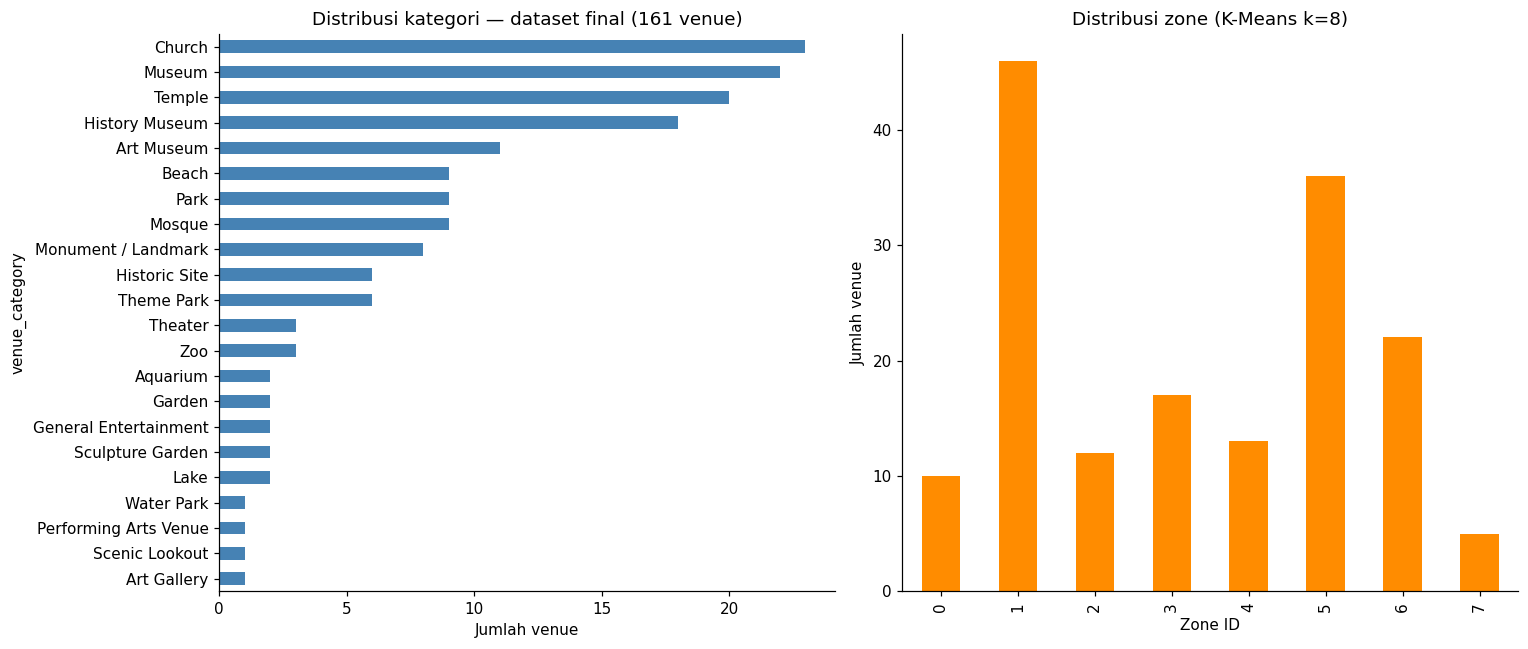


Venue per zone:
  Zone 0 (10 venue): {'Museum': np.int64(3), 'Art Museum': np.int64(2)}
  Zone 1 (46 venue): {'History Museum': np.int64(11), 'Museum': np.int64(6)}
  Zone 2 (12 venue): {'Church': np.int64(4), 'Temple': np.int64(3)}
  Zone 3 (17 venue): {'Temple': np.int64(10), 'Church': np.int64(2)}
  Zone 4 (13 venue): {'Church': np.int64(5), 'Museum': np.int64(3)}
  Zone 5 (36 venue): {'Beach': np.int64(8), 'Church': np.int64(4)}
  Zone 6 (22 venue): {'Museum': np.int64(5), 'Church': np.int64(4)}
  Zone 7 (5 venue): {'Monument / Landmark': np.int64(1), 'Theme Park': np.int64(1)}


In [24]:
# [STATS] Dataset final — distribusi kategori + zone
if os.path.exists(config.CLUSTERED_VENUES_CSV):
    df = pd.read_csv(config.CLUSTERED_VENUES_CSV)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    df['venue_category'].value_counts().plot(
        kind='barh', ax=axes[0], color='steelblue',
        title=f'Distribusi kategori — dataset final ({len(df)} venue)')
    axes[0].invert_yaxis()
    axes[0].set_xlabel('Jumlah venue')

    df['zone_id'].value_counts().sort_index().plot(
        kind='bar', ax=axes[1], color='darkorange',
        title=f'Distribusi zone (K-Means k={config.CLUSTER_K})')
    axes[1].set_xlabel('Zone ID')
    axes[1].set_ylabel('Jumlah venue')
    plt.tight_layout()
    plt.show()

    print('\nVenue per zone:')
    for z in sorted(df['zone_id'].unique()):
        top = df[df['zone_id']==z]['venue_category'].value_counts().head(2)
        print(f'  Zone {z} ({(df["zone_id"]==z).sum()} venue): {dict(top)}')